# Optically Shallow / Deep Water Delineation

[![image](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/opengeos/geoai/blob/main/docs/examples/optically_shallow_deep.ipynb)

This notebook demonstrates how to perform optically shallow and deep water classification in Sentinel-2 imagery using  and the  library.

## Install Package

Ensure  and  are installed in your environment.

In [ ]:
%pip install geoai-py opticallyshallowdeep

### A. Classification for Level-1C (L1C) SAFE Files

I0000 00:00:1785140742.719359   35538 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785140742.819054   35538 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785140744.611555   35538 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.



=== ENVIRONMENT ===
OSD version: 1.2.3.post1
Start time: 2026-07-27 08:25:45
file_L1C: /teamspace/studios/this_studio/data/S2B_MSIL1C_20190725T100039_N0208_R122_T33UWP_20190725T123957.SAFE
file_L2R: None
folder_out: /tmp/tmpsh8qeom0

=== PRE-PROCESSING ===
Making multi-band geotiff: /tmp/tmpsh8qeom0/S2B_MSIL1C_20190725T100039_N0208_R122_T33UWP_20190725T123957.tif
Done
If input is SR product: False
Trained model to use: /home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/opticallyshallowdeep/models/TOA.h5
Making cloud mask...
Done

=== PREDICTING OSW/ODW ===
Strip 1/5
  Processing 145093 water pixels


I0000 00:00:1785141033.665773   35906 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785141033.665780   35909 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785141033.665820   35908 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785141033.665790   35907 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point ro

  Complete
Strip 2/5
  Processing 138381 water pixels
  Complete
Strip 3/5
  Processing 136868 water pixels
  Complete
Strip 4/5
  Processing 95487 water pixels
  Complete
Strip 5/5
  Processing 191268 water pixels
  Complete
Image OSW/ODW completed, dimension: (10980, 10980, 3)
Finish time: 2026-07-27 08:39:46


'osd_probability.tif'

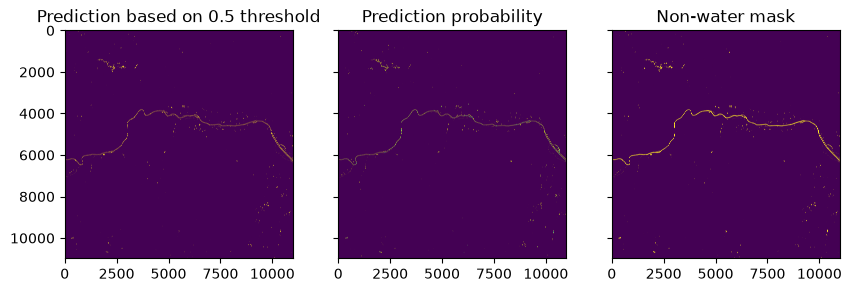

In [1]:
import geoai
import rasterio
from rasterio.enums import Resampling
import matplotlib.pyplot as plt
import numpy as np

# 1. Define file paths
# Path to Sentinel-2 Level-1C SAFE directory
file_L1C = "/teamspace/studios/this_studio/data/S2B_MSIL1C_20190725T100039_N0208_R122_T33UWP_20190725T123957.SAFE"

# Output probability GeoTIFF path
out_prob = "osd_probability.tif"

# 2. Run classification
geoai.classify_optically_shallow_deep(
    image=file_L1C,
    output=out_prob,
    to_log=True  #False
)

/tmp/ipykernel_35538/3504039507.py:9: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  prob = src.read(1, out_shape=(1, h, w), resampling=Resampling.nearest)


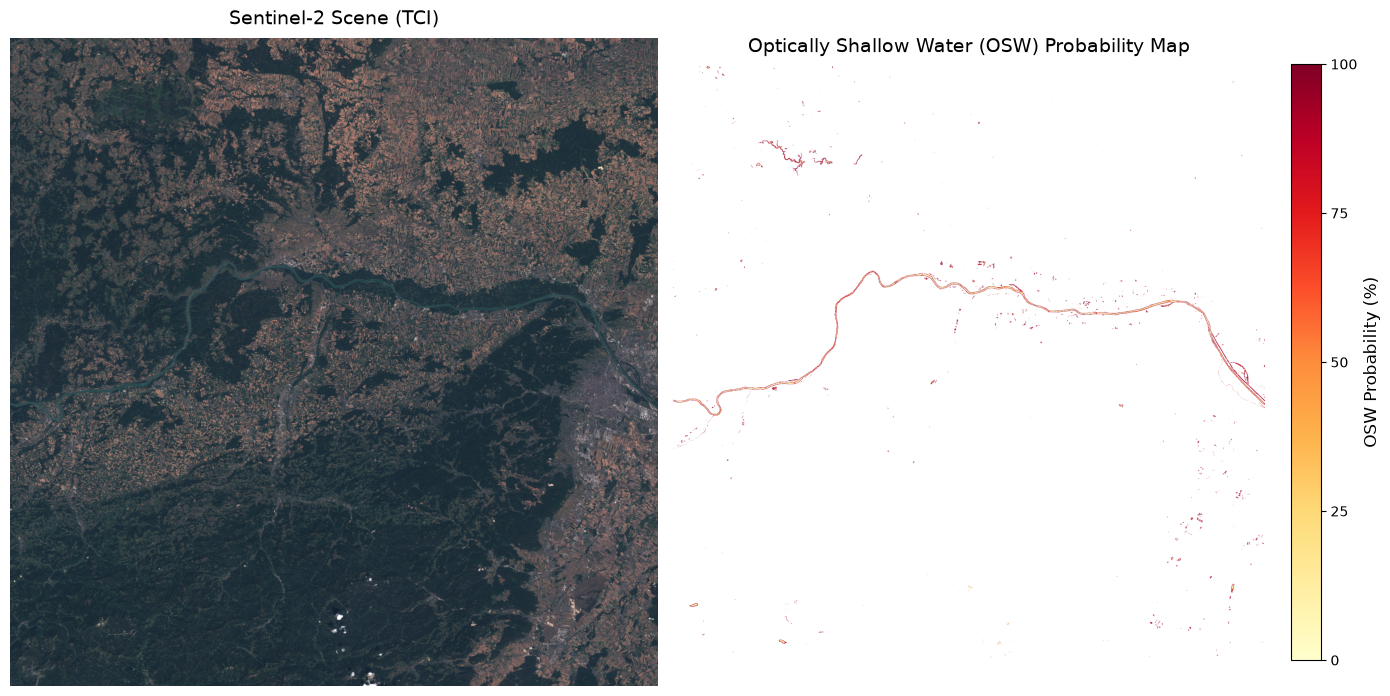

In [4]:
tci_path = f"{file_L1C}/GRANULE/L1C_T33UWP_A012446_20190725T100415/IMG_DATA/T33UWP_20190725T100039_TCI.jp2"

# 3. Read and downsample raster data for visualization
with rasterio.open(tci_path) as src:
    h, w = src.height // 5, src.width // 5
    rgb = src.read([1, 2, 3], out_shape=(3, h, w), resampling=Resampling.bilinear)
    rgb = np.transpose(rgb, (1, 2, 0))
with rasterio.open(out_prob) as src:
    prob = src.read(1, out_shape=(1, h, w), resampling=Resampling.nearest)
    prob_masked = np.ma.masked_where(prob == 255, prob)

# 4. Plot TCI Scene and OSW Probability Map side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Left: True Color Image (TCI)
axes[0].imshow(rgb)
axes[0].set_title("Sentinel-2 Scene (TCI)", fontsize=14, pad=10)
axes[0].axis("off")

# Right: OSW Probability Map
im = axes[1].imshow(prob_masked, cmap="YlOrRd", vmin=0, vmax=100)
axes[1].set_title("Optically Shallow Water (OSW) Probability Map", fontsize=14, pad=10)
axes[1].axis("off")

# Add colorbar
cbar = fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
cbar.set_label("OSW Probability (%)", fontsize=12)
cbar.set_ticks([0, 25, 50, 75, 100])
plt.tight_layout()
plt.show()

### B. Classification for ACOLITE Level-2R (L2R) Files

For ACOLITE Level-2R (surface reflectance) NetCDF files, the original Level-1C SAFE directory is also provided to extract the built-in cloud mask.

In [ ]:
import geoai

# Input Level-1C SAFE file (for cloud mask)
file_L1C = "/teamspace/studios/this_studio/data/S2B_MSIL1C_20190725T100039_N0208_R122_T33UWP_20190725T123957.SAFE"

# ACOLITE Level-2R NetCDF file
file_L2R = "folder/S2B_MSI_2023_09_28_15_44_58_T17MNP_L2R.nc"

# Output probability GeoTIFF path
out_prob = "osd_probability_l2r.tif"

# Run classification with surface reflectance
geoai.classify_optically_shallow_deep(
    image=file_L1C,
    output=out_prob,
    acolite_l2r=file_L2R,
    to_log=True
)

### Interactive Visualization with Leafmap

In [5]:
import leafmap

m = leafmap.Map()
m.add_basemap("HYBRID")
m.add_raster("osd_probability.tif", cmap="viridis", layer_name="OSW Probability")
m.fit_bounds(leafmap.image_bounds("osd_probability.tif"))
m

Map(center=[48.254416000000006, 15.746498500000001], controls=(ZoomControl(options=['position', 'zoom_in_text'…